In [1]:
%load_ext autoreload
%autoreload 2
import pprint, json, math, os, sys, camelot
# sys.path.append(os.path.abspath(dir_path))
import subprocess

import fitz, pdfplumber, ocrmypdf, pprint
import pandas as pd
import numpy as np
from collections import defaultdict
from app.parse_table import TableParser
from app.utils import Helper, PDFTableExtractor

helper = Helper()
def determine_numeric_cols(df:pd.DataFrame, threshold = 0.6)->list:

    is_numeric_like = lambda col: (lambda s: sum(c in "0123456789,.- " for c in s) / len(s) if len(s) else 0)(" ".join(col.astype(str)))
    
    numeric_cols = []
    df_cols = df.columns
    # print(df_cols)
    for col in df_cols:
        ratio = is_numeric_like(df[col])
        if ratio>=threshold:
            numeric_cols.append(col)
    return numeric_cols

filter_numeric = lambda x: "".join(c for c in str(x) if c in "0123456789.,-")
encode_utf = lambda text: str(text).encode('latin1', errors='ignore').decode('utf-8', errors='ignore')

In [ ]:
import cv2

def detect_tables(image, width_tolerance: int = 250, height_tolerance: int = 150) :

    # The image becomes black background with white foreground
    # Typically, table lines (borders) are now white
    # This makes them easy to isolate using morphology

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray,180,255,cv2.THRESH_BINARY_INV)[1]
    
    
    # (80,1) → very wide and thin → detects horizontal lines
    # (1,80) → very tall and thin → detects vertical lines

    # Think of them like "templates" that slide over the image to match line shapes.
    
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(80, 1))
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(1, 80))


    # Horizontal detection:
    # Removes everything except long horizontal lines
    # Small blobs/text disappear

    # Vertical detection:
    # Removes everything except long vertical lines

    hor = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,h_kernel,iterations=2)
    ver = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,v_kernel,iterations=2)
    table_mask = cv2.add(hor,ver) #Result: a grid-like structure
    
    contours, _ = cv2.findContours(table_mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    # Detects connected regions in the mask
    # Each contour could be a table or part of it
    tables = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # w > 250: wide enough
        # h > 100: tall enough
        if w > width_tolerance and h > height_tolerance:
            tables.append((x, y, w, h))

    final_bbox = sorted(tables,key=lambda b: b[1])
    
    return final_bbox
    

path = r"TEST.png"
image = cv2.imread(path)
data = detect_tables(image)
print(data)

In [ ]:
#both row and col automate
import pandas as pd
from app.utils import Helper
from table_ft import FetchTable
from pathlib import Path
jsn_path = r"annot.json5"
helper = Helper()
configs = helper.load_json5(jsn_path)

pdf_path = r"KOT.pdf"
xls_path = pdf_path.replace(".pdf",".xlsx")
#currently using automatic handler
content= FetchTable.excel_handler(pdf_path,configs)
# content.to_excel(pdf_path.replace(".pdf",".xlsx"), index = None)

with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
    for x, data in content.items():
        for frame in data:
            pgn = frame["page"]
            tbl = frame["table"]
            df = frame["df"]
            sheet_name = f"page_{pgn}_{tbl}"
            df.to_excel(writer, sheet_name=sheet_name, index=False)


In [ ]:
import pandas as pd
from app.utils import Helper
from table_ft import FetchTable
jsn_path = r"annot.json5"
helper = Helper()
configs = helper.load_json5(jsn_path)

pdf_path = r"84_30-Apr-26_1_IF.pdf"
xls_path = pdf_path.replace(".pdf",".xlsx")
# print(f"CONFIG: {configs}")

content = FetchTable.excel_handler(pdf_path,configs)



In [6]:
with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
    for x, data in content.items():
        for frame in data:
            pgn = frame["page"]
            tbl = frame["table"]
            df = frame["df"]
            sheet_name = f"page_{pgn}_{tbl}"
            df.to_excel(writer, sheet_name=sheet_name, index=False)

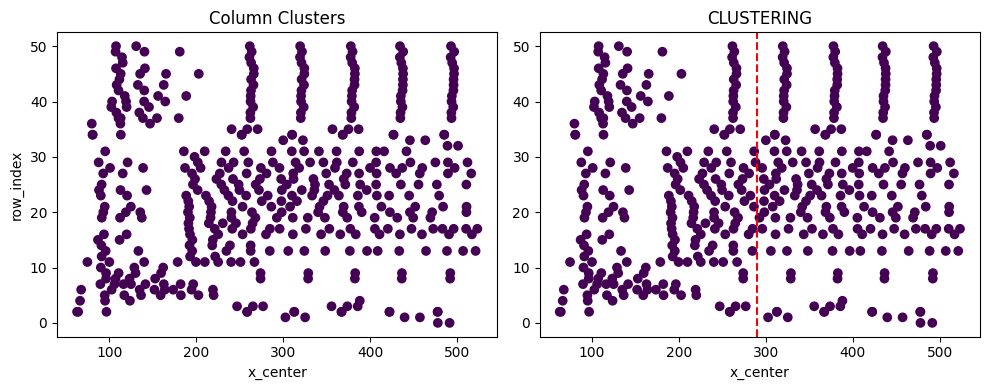

Detected centers [np.float64(290.1709493940042)]


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_from_debug_cols(debug_cols, eps=15, min_samples=5):

    xs = []
    ys = []
    col_labels = []

    for col_idx, rows in debug_cols.items():
        for row in rows:
            r_idx = row["row_index"]

            for item in row["items"]:
                xs.append(item["x_center"])
                ys.append(r_idx)
                col_labels.append(col_idx)  # YOUR assigned column

    xs = np.array(xs)
    ys = np.array(ys)
    from sklearn.cluster import DBSCAN
    X = xs.reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    db_labels = db.labels_

    # ---- Plot ----
    plt.figure(figsize=(10, 4))


    plt.subplot(1, 2, 1)
    plt.scatter(xs, ys, c=col_labels)
    plt.title("Column Clusters")
    plt.xlabel("x_center")
    plt.ylabel("row_index")


    plt.subplot(1, 2, 2)
    plt.scatter(xs, ys, c=db_labels)
    plt.title("CLUSTERING")
    plt.xlabel("x_center")

    
    clusters = {}
    for x, label in zip(xs, db_labels):
        if label == -1:
            continue
        clusters.setdefault(label, []).append(x)

    centers = sorted(np.mean(v) for v in clusters.values())

   
    for c in centers:
        plt.axvline(c, linestyle="--", linewidth=1.5, color="red")

    plt.tight_layout()
    plt.show()

    print("Detected centers", centers)


for x, data in content.items():
    for frame in data:
        debug_c = frame["debug_c"]
        plot_from_debug_cols(debug_c)

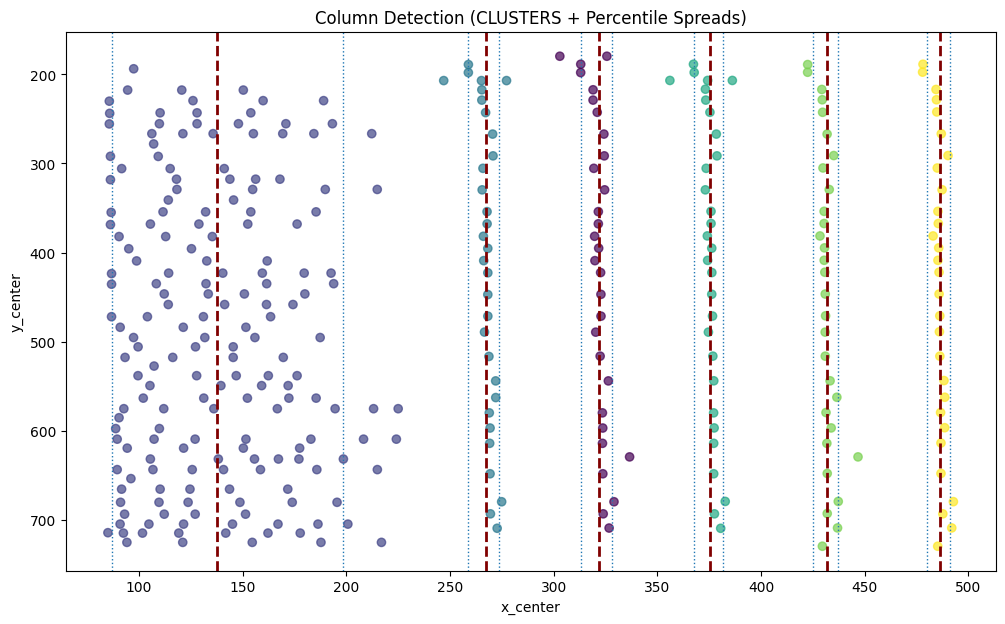

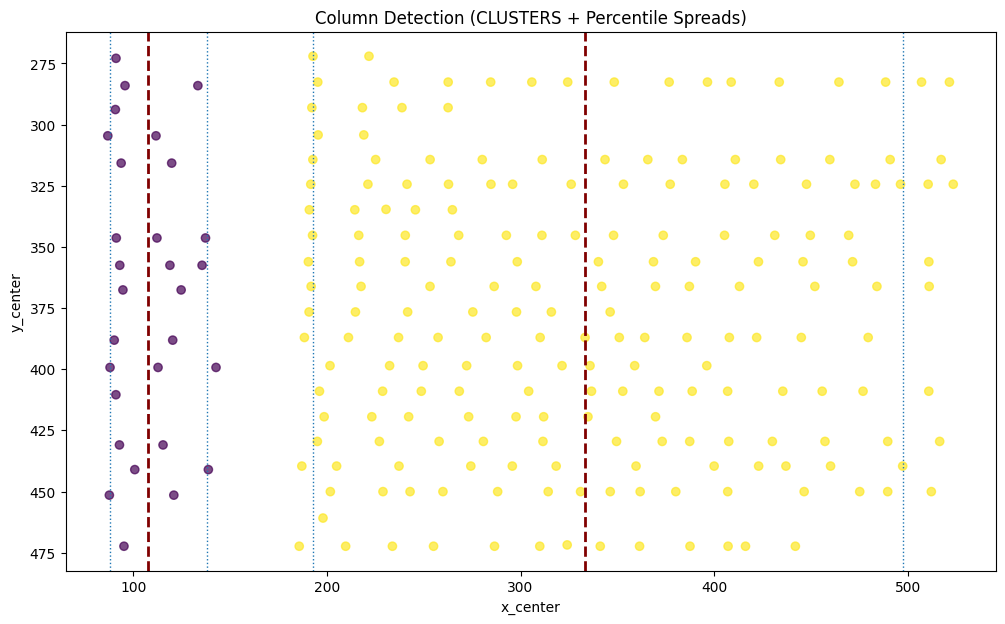

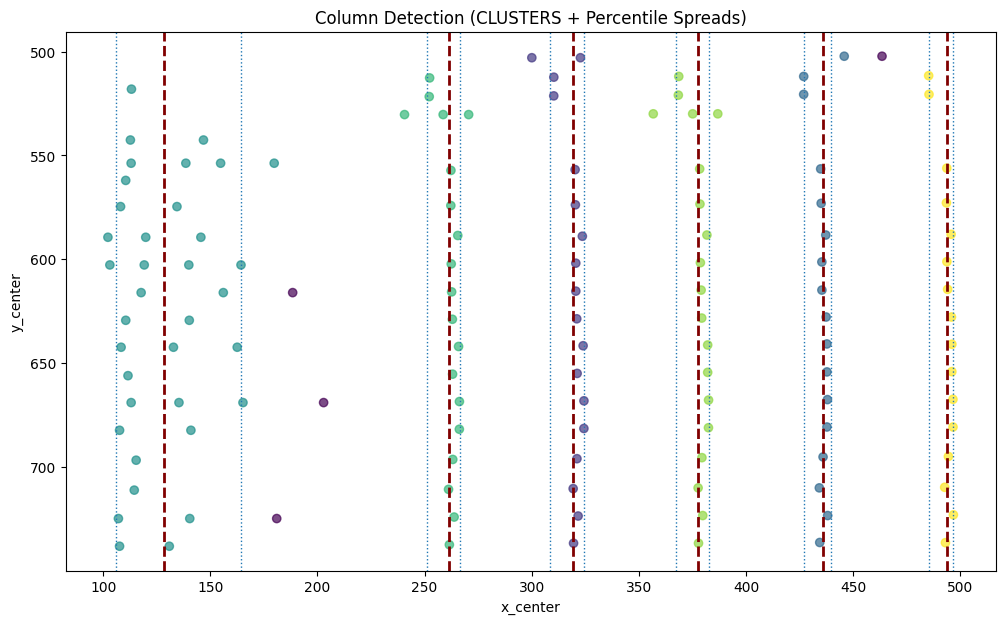

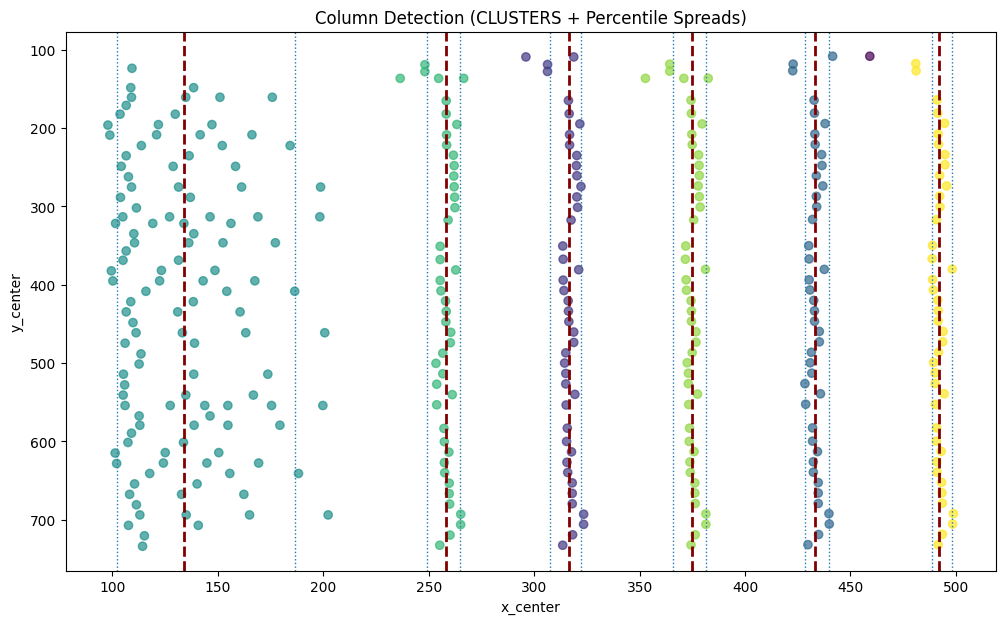

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

def plot_spreads_from_items(items, eps=15, min_samples=5):

    # ---- Extract data ----
    xs = np.array([i["x_center"] for i in items])
    ys = np.array([i["y_center"] for i in items])

    # ---- DBSCAN ----
    X = xs.reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_

    # ---- Build clusters ----
    clusters = {}
    for x, label in zip(xs, labels):
        if label == -1:
            continue
        clusters.setdefault(label, []).append(x)

    # ---- Compute percentile spreads ----
    col_spans = []

    for label, col_xs in clusters.items():
        col_xs = np.array(col_xs)

        left = np.percentile(col_xs, 5)
        right = np.percentile(col_xs, 95)
        center = np.mean(col_xs)

        col_spans.append({
            "center": center,
            "left": left,
            "right": right
        })

    # sort for clean visualization
    col_spans = sorted(col_spans, key=lambda x: x["center"])

    # ---- Plot ----
    plt.figure(figsize=(12, 7))

    # scatter points colored by DBSCAN cluster
    plt.scatter(xs, ys, c=labels, alpha=0.7)

    # ---- draw spreads ----
    for col in col_spans:
        # center line
        plt.axvline(col["center"], linestyle="--", linewidth=2, color = "maroon")

        # spread boundaries
        plt.axvline(col["left"], linestyle=":", linewidth=1)
        plt.axvline(col["right"], linestyle=":", linewidth=1)

    plt.title("Column Detection (CLUSTERS + Percentile Spreads)")
    plt.xlabel("x_center")
    plt.ylabel("y_center")

    # IMPORTANT: invert to match PDF coordinate system
    plt.gca().invert_yaxis()

    plt.show()

    return col_spans


for x, data in content.items():
    for frame in data:     
        debug_c = frame["items"]
        plot_spreads_from_items(debug_c)

In [ ]:
import fitz  # PyMuPDF
import easyocr
import cv2
import numpy as np

pdf_path = r"C:\Users\kaustubh.keny\Downloads\C_MAST.pdf"
doc = fitz.open(pdf_path)
n_doc = fitz.open()

for idx in range(0,doc.page_count):
    # print(f"Page_{idx}")
    page = doc[idx]
    pix = page.get_pixmap()
    img_path = f"output_page_{idx}.png"
    pix.save(img_path)
    
    reader = easyocr.Reader(['en'])
    ocr_results = reader.readtext(
        img_path,
        decoder="beamsearch",
        text_threshold=.5
        )
    
    
    n_page = n_doc.new_page(width=page.rect.width, height=page.rect.height)
    
    for bbox, text, conf in ocr_results:
        # Take top-left point of bounding box
        x, y = bbox[0]

        # Adjust Y slightly
        # y += 10

        n_page.insert_text(
            (x, y),
            text,
            fontsize=10,
            color=(0, 0, 0)
        )

n_doc.save("WE_TRIED.pdf")
    